## Домашка 2
<h4><em>«Одно Кольцо, чтоб править всеми,<br>
Одно Кольцо, чтоб всех найти,<br>
Одно Кольцо, чтоб собрать всех в тени<br>
И заковать их всех во Тьме»</em><br>
— <em>Властелин колец</em>
</h4>

Эта домашка про приоритизацию метрик. За неё можно получить максимум 12 баллов.

**Дедлайны**   
Мягкий дедлайн: 27.09.2026 23:59 по МСК.   
Жесткий дедлайн: 04.10.2026 23:59 по МСК.

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.
После жесткого дедлайна работы не принимаются.

**Правила сдачи**  
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_2). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip)

In [4]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [5]:
import zipfile

with zipfile.ZipFile('hw_2_data.zip') as archive:
    archive.extractall('.')

### Warm up

#### 1. Game dev — 2 балла
У вас есть данные о событиях в мобильной игре. Рассчитайте и визуализируйте:
- User Stickiness — отношение DAU к MAU (MAU рассчитывайте скользящим окном 30 дней для каждой даты только для полного окна)
- ARPDAU
- Paying Share — доля платящих пользователей
- Sessions per User — среднее число сессий на пользователя
- Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
- Avg Attempts per Session — среднее число попыток на сессию

*Смотрим на подневную динамику

In [6]:
df_game = pd.read_csv('data/hw_2_gamedev.csv', index_col=0)
df_game.head()

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871


Описание данных (уникальный ключ session_id)

- session_id — уникальный идентификатор сессии
- user — уникальный идентификатор юзера
- date — дата
- revenue — суммарная выручка на сессию
- attempts — число попыток на сессию
- session_length_sec — длина сессии в секундах

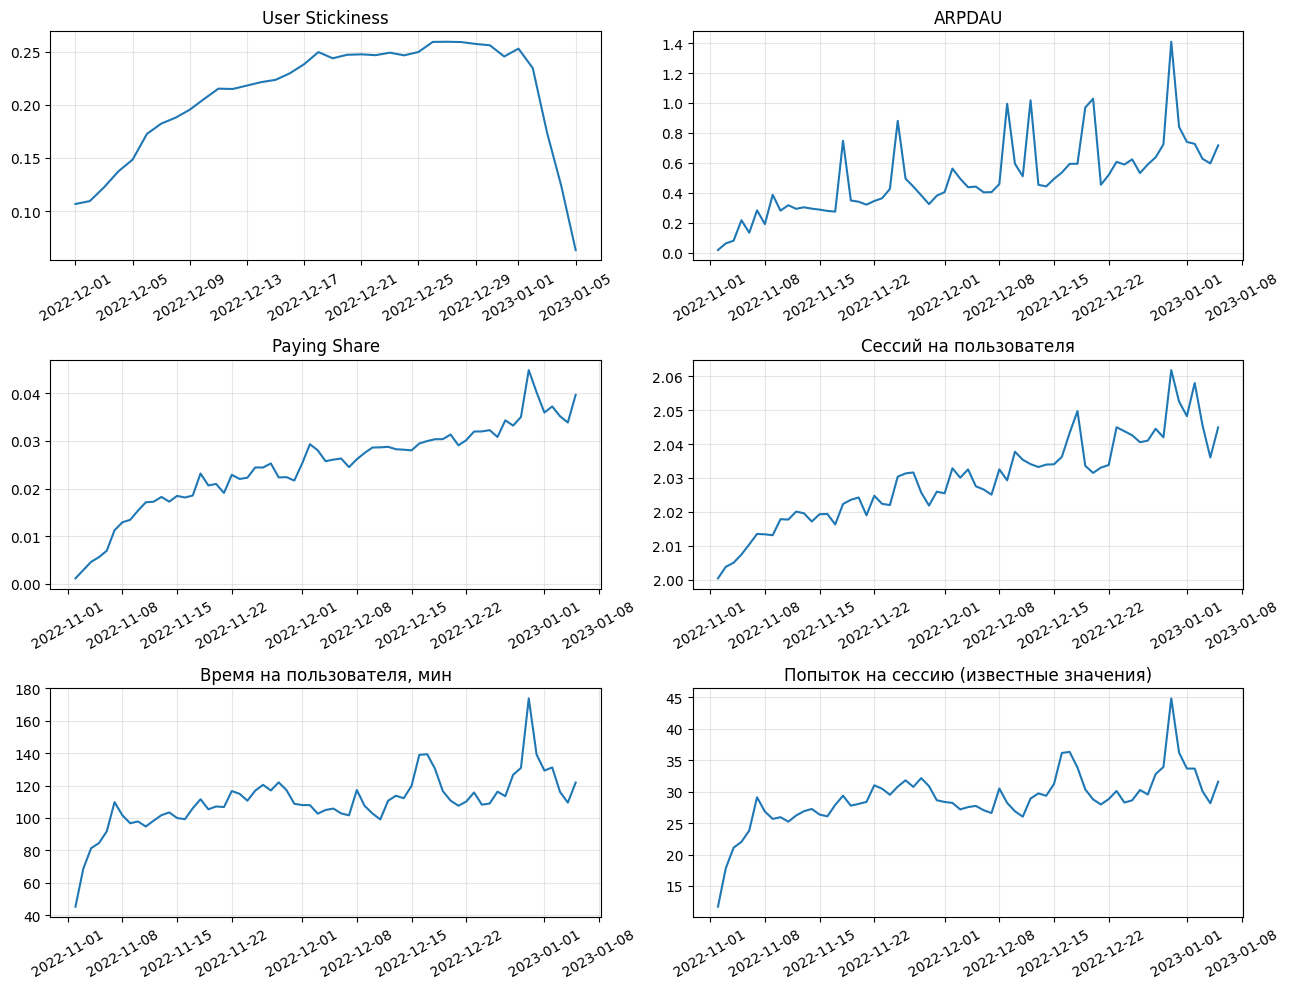

In [7]:
# your code is here

df_game['date'] = pd.to_datetime(df_game['date'])
# Пропуск выручки считаем отсутствием покупки.
df_game['revenue'] = df_game['revenue'].fillna(0)

game_day = df_game.groupby('date').agg(
    dau=('user', 'nunique'),
    revenue=('revenue', 'sum'),
    sessions=('session_id', 'nunique'),
    time_seconds=('session_length_sec', 'sum'),
    avg_attempts=('attempts', 'mean')
)
paying = df_game[df_game['revenue'] > 0].groupby('date')['user'].nunique()
game_day['paying_users'] = paying.reindex(game_day.index, fill_value=0)

# MAU считаем только после появления полного окна из 30 календарных дней.
game_day['mau'] = float('nan')
for date in game_day.index:
    start = date - timedelta(days=29)
    if start >= df_game['date'].min():
        users = df_game.loc[df_game['date'].between(start, date), 'user']
        game_day.loc[date, 'mau'] = users.nunique()

game_day['stickiness'] = game_day['dau'] / game_day['mau']
game_day['arpdau'] = game_day['revenue'] / game_day['dau']
game_day['paying_share'] = game_day['paying_users'] / game_day['dau']
game_day['sessions_per_user'] = game_day['sessions'] / game_day['dau']
game_day['daily_play_time_min'] = game_day['time_seconds'] / game_day['dau'] / 60

metrics = ['stickiness', 'arpdau', 'paying_share', 'sessions_per_user',
           'daily_play_time_min', 'avg_attempts']
titles = ['User Stickiness', 'ARPDAU', 'Paying Share', 'Сессий на пользователя',
          'Время на пользователя, мин', 'Попыток на сессию (известные значения)']

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.plot(game_day.index, game_day[metric])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 2. Ride hailing  — 2 балла
У вас есть данные из приложения такси. Рассчитайте и визуализируйте:
- Ride Completion Rate — CR из заказа в завершенную поездку
- Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
- Cancellation Rate — доля отмененных заказов
- Rides per Driver — среднее число поездок на водителя
- Avg Ride Check — средний чек поездки
- Отношение RTA к ETA (что измеряет эта метрика?)

*Смотрим на подневную динамику

In [8]:
df_rh = pd.read_csv('data/hw_2_taxi.csv')

In [9]:
df_rh.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Описание данных (уникальный ключ order_uid)

- date — дата создания заказа
- time — время создания заказа
- order_uid — уникальный идентификатор заказа
- order_status — статус заказа
- passenger_id — уникальный идентификатор пассажира
- vehicle_type — тип транспорта
- pickup_location — место отправления
- drop_location — место назначения
- ETA — прогнозное время прибытия водителя на место отправления (estimated time of arrival)
- RTA — реальное время прибытия водителя на место отправления (real time of arrival)
- driver_id — уникальный идентификатор водителя
- cancelled_rides_by_customer — флаг отмены поездки пассажиром
- reason_for_cancelling_by_customer — причина отмены поездки пассажиром
- cancelled_rides_by_driver — флаг отмены поездки водителем
- driver_cancellation_reason — причина отмены поездки водителем
- incomplete_rides — флаг незавершенной поездки
- incomplete_rides_reason — причина незавершенной поездки
- fare — цена поездки
- ride_distance – расстояние поездки
- driver_ratings — рейтинг водителя
- customer_rating — рейтинг пассажира
- payment_method – способ оплаты

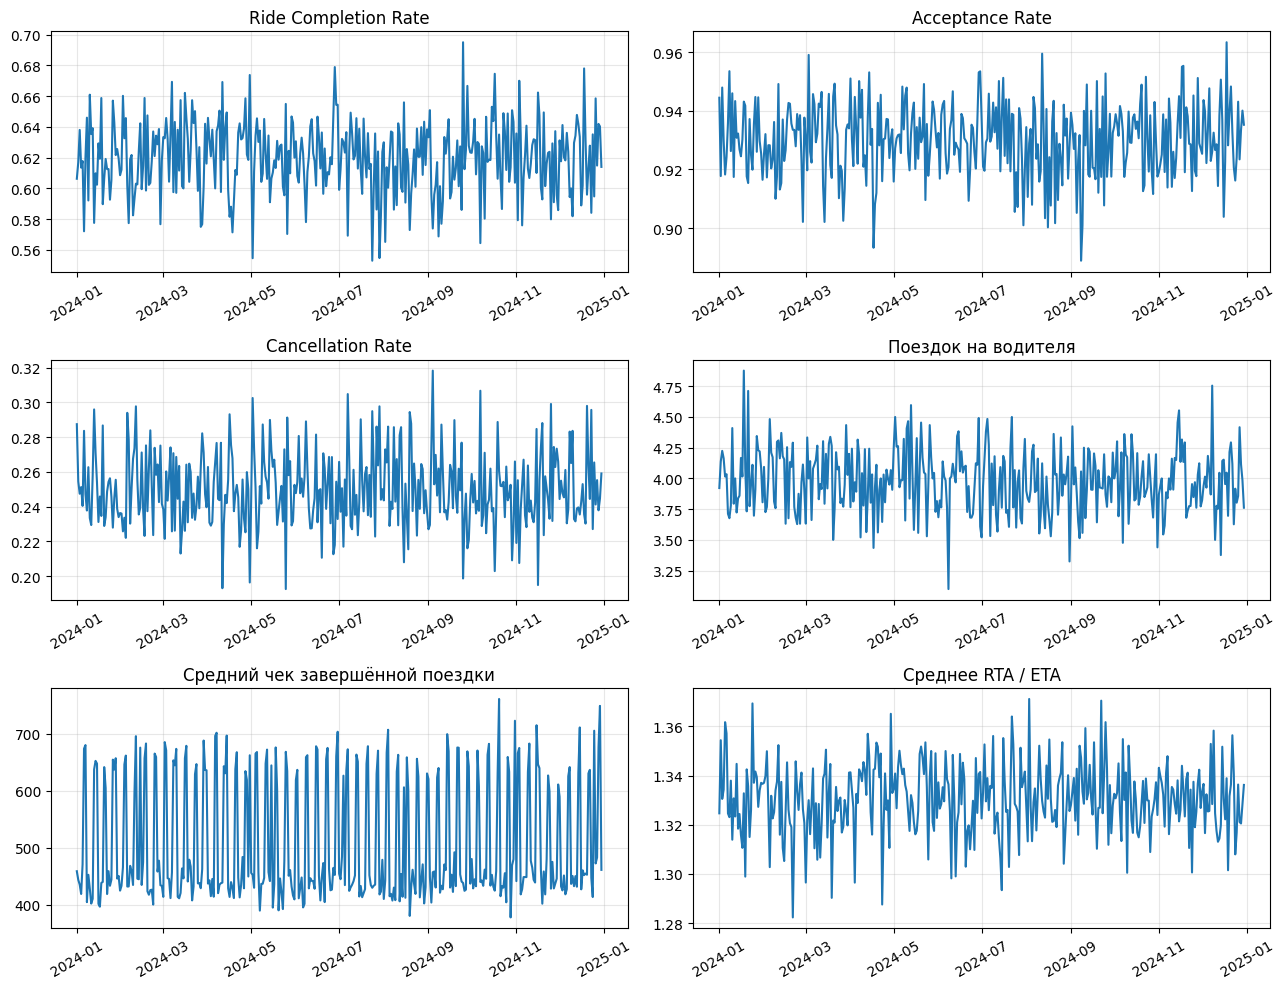

In [10]:
# your code is here

df_rh['date'] = pd.to_datetime(df_rh['date'])
df_rh['completed'] = df_rh['order_status'] == 'Completed'
df_rh['accepted'] = df_rh['order_status'] != 'No Driver Found'
df_rh['cancelled'] = df_rh['order_status'].isin(['Cancelled by Customer', 'Cancelled by Driver'])

# Сначала отношение в каждом заказе, затем среднее по заказам за день.
valid_time = (df_rh['ETA'] > 0) & (df_rh['RTA'] >= 0)
df_rh['rta_eta'] = (df_rh['RTA'] / df_rh['ETA']).where(valid_time)

taxi_day = df_rh.groupby('date').agg(
    orders=('order_uid', 'nunique'),
    completed=('completed', 'sum'),
    accepted=('accepted', 'sum'),
    cancelled=('cancelled', 'sum'),
    drivers=('driver_id', 'nunique'),
    rta_eta=('rta_eta', 'mean')
)
taxi_day['completion_rate'] = taxi_day['completed'] / taxi_day['orders']
taxi_day['acceptance_rate'] = taxi_day['accepted'] / taxi_day['orders']
taxi_day['cancellation_rate'] = taxi_day['cancelled'] / taxi_day['orders']

# В знаменателе все водители, назначенные на заказы за день, включая отменённые.
taxi_day['rides_per_driver'] = taxi_day['completed'] / taxi_day['drivers'].replace(0, float('nan'))
taxi_day['avg_check'] = df_rh[df_rh['completed']].groupby('date')['fare'].mean()

# RTA / ETA показывает, во сколько раз фактическое ожидание отличается от обещанного.
# 1 — совпало, больше 1 — дольше обещанного, меньше 1 — водитель приехал раньше.
metrics = ['completion_rate', 'acceptance_rate', 'cancellation_rate',
           'rides_per_driver', 'avg_check', 'rta_eta']
titles = ['Ride Completion Rate', 'Acceptance Rate', 'Cancellation Rate',
          'Поездок на водителя', 'Средний чек завершённой поездки', 'Среднее RTA / ETA']

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.plot(taxi_day.index, taxi_day[metric])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Case Study. Запуск подкастов в стриминговом сервисе 🎧

**Легенда**  
Вы работаете продуктовым аналитиком в музыкальном стриминговом сервисе. Недавно в продукте запустился раздел с подкастами. Команда, отвечающая за запуск, хочет понять, стоит ли масштабировать и продвигать этот формат.

In [11]:
df_music_logs = pd.read_parquet('data/hw_2_streaming_logs.pqt')
df_music_subs = pd.read_parquet('data/hw_2_streaming_subs.pqt')

In [12]:
df_music_logs.head()

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0


In [13]:
df_music_subs.head()

,uid,start_date,end_date
0,600,2024-08-08,NaT
1,700,2024-03-29,NaT
2,800,2024-06-13,NaT
3,1100,2024-11-19,NaT
4,1400,2024-12-01,NaT


Описание данных hw_2_streaming_logs:

- datetime — дата-время взаимодействия с контентом
- uid — уникальный идентификатор пользователя
- item_id — уникальный идентификатор трека/эпизода
- played_ratio_pct — процент от длительности, который был воспроизведен
- track_length_seconds – длина трека/эпизода в секундах
- content_type — тип контента: музыка или подкаст
- is_first_date — флаг, является ли эта дата первой для пользователя в продукте

Описание данных hw_2_streaming_subs:

- uid — уникальный идентификатор пользователя
- start_date — дата начала подписки
- end_date — дата окончания подписки

#### 3. Метрики роста  — 2 балла

Рассчитайте и визуализируйте:
- DAU, MAU, WAU;
- Количество новых премиум-подписчиков (за неделю и месяц);
- Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).

Сделайте выводы:
- Есть ли выраженный тренд?
- Нет ли подозрений, что с раскаткой раздела что-то могло пойти не так (изменение тренда, выраженные ступеньки)?
- Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?

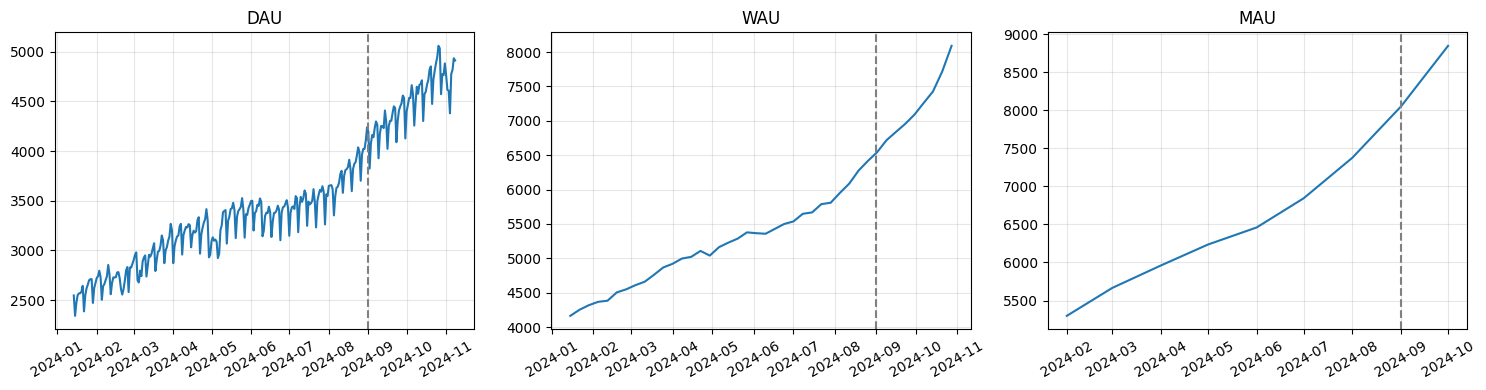

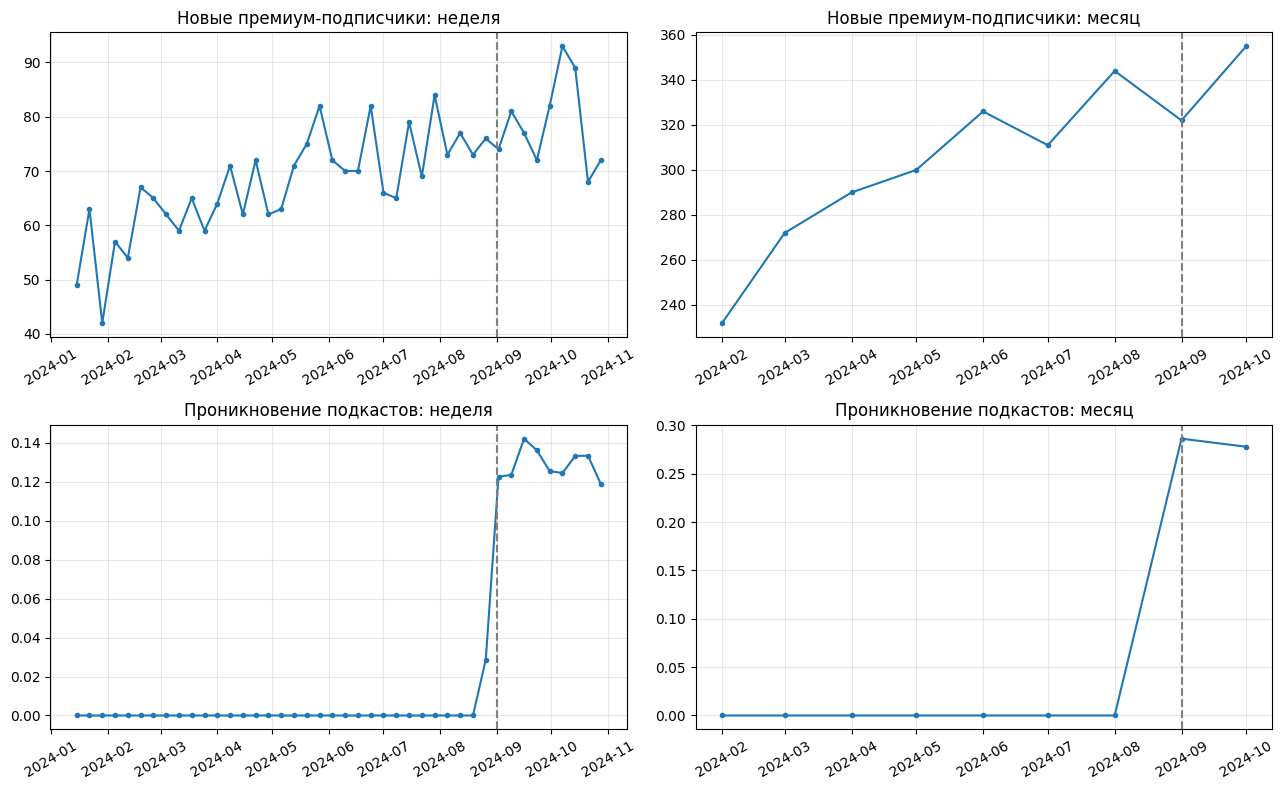

,active_users,new_premium,podcast_users,penetration
month,,,,
2024-02-01,5299,232,0,0.000000
2024-03-01,5666,272,0,0.000000
2024-04-01,5961,290,0,0.000000
2024-05-01,6236,300,0,0.000000
2024-06-01,6460,326,0,0.000000
2024-07-01,6844,311,0,0.000000
2024-08-01,7376,344,0,0.000000
2024-09-01,8050,322,2305,0.286335
2024-10-01,8846,355,2459,0.277979


In [14]:
df_music_logs['content_type'] = df_music_logs['content_type'].astype('category')
df_music_logs['date'] = df_music_logs['datetime'].dt.normalize()

start = df_music_logs['datetime'].min()
end = df_music_logs['datetime'].max()

# Первый и последний дни выгрузки неполные.
full_start = start.normalize() + timedelta(days=1)
full_end = end.normalize() - timedelta(days=1)

weeks = []
for week in pd.period_range(start, end, freq='W-SUN'):
    if week.start_time >= full_start and week.end_time.normalize() <= full_end:
        weeks.append(week)

months = []
for month in pd.period_range(start, end, freq='M'):
    if month.start_time >= full_start and month.end_time.normalize() <= full_end:
        months.append(month)

week_dates = [week.start_time for week in weeks]
month_dates = [month.start_time for month in months]

# Пользователь учитывается один раз в день, сколько бы треков он ни включил.
user_day = df_music_logs[['uid', 'date']].drop_duplicates()
user_day['week'] = user_day['date'].dt.to_period('W-SUN').dt.start_time
user_day['month'] = user_day['date'].dt.to_period('M').dt.start_time

dau = user_day.groupby('date')['uid'].nunique()
dau = dau.reindex(pd.date_range(full_start, full_end), fill_value=0)

growth_week = user_day.groupby('week')['uid'].nunique().to_frame('active_users')
growth_week = growth_week.loc[week_dates].copy()

growth_month = user_day.groupby('month')['uid'].nunique().to_frame('active_users')
growth_month = growth_month.loc[month_dates].copy()

podcasts = df_music_logs[df_music_logs['content_type'] == 'podcast'].copy()
podcasts['week'] = podcasts['date'].dt.to_period('W-SUN').dt.start_time
podcasts['month'] = podcasts['date'].dt.to_period('M').dt.start_time
launch = podcasts['datetime'].min().normalize()

# Для каждого пользователя берём начало его первой подписки.
first_sub = df_music_subs.groupby('uid')['start_date'].min()

# Недельные показатели.
new_subs_week = first_sub.dt.to_period('W-SUN').dt.start_time.value_counts()
podcast_users_week = podcasts.groupby('week')['uid'].nunique()

growth_week['new_premium'] = new_subs_week.reindex(growth_week.index, fill_value=0)
growth_week['podcast_users'] = podcast_users_week.reindex(growth_week.index, fill_value=0)
growth_week['penetration'] = growth_week['podcast_users'] / growth_week['active_users']

# Месячные показатели.
new_subs_month = first_sub.dt.to_period('M').dt.start_time.value_counts()
podcast_users_month = podcasts.groupby('month')['uid'].nunique()

growth_month['new_premium'] = new_subs_month.reindex(growth_month.index, fill_value=0)
growth_month['podcast_users'] = podcast_users_month.reindex(growth_month.index, fill_value=0)
growth_month['penetration'] = growth_month['podcast_users'] / growth_month['active_users']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, values, title in [(axes[0], dau, 'DAU'),
                           (axes[1], growth_week['active_users'], 'WAU'),
                           (axes[2], growth_month['active_users'], 'MAU')]:
    ax.plot(values.index, values)
    ax.axvline(launch, color='gray', linestyle='--')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, metric, title in [(0, 'new_premium', 'Новые премиум-подписчики'),
                           (1, 'penetration', 'Проникновение подкастов')]:
    for col, table, period_name in [(0, growth_week, 'неделя'), (1, growth_month, 'месяц')]:
        ax = axes[row, col]
        ax.plot(table.index, table[metric], marker='o', markersize=3)
        ax.axvline(launch, color='gray', linestyle='--')
        ax.set_title(title + ': ' + period_name)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
growth_month


**Выводы к заданию 3**

DAU, WAU и MAU растут. MAU увеличился с 5 299 в феврале до 8 846 в октябре. Ближе к осени рост ускоряется, но это началось ещё до подкастов. Первые события подкастов появляются в данных 1 сентября 2024 года. После этой даты резкого падения аудитории или заметного перелома тренда нет, поэтому явных признаков проблем с запуском не вижу.

Новых премиум-подписчиков в целом становится больше: 232 в феврале и 355 в октябре. При этом в августе их было 344, а в сентябре — 322. Выраженного скачка подписок сразу после запуска подкастов нет.

В сентябре подкасты попробовали 28,63% месячной аудитории, в октябре — 27,80%. Доля немного снизилась, но число слушателей выросло с 2 305 до 2 459. Недельное проникновение после первой недели держится примерно на уровне 12–14%. Интерес к разделу сохраняется, но по двум месяцам ещё нельзя уверенно судить о формировании привычки или эффекте новизны.

Точки на графиках стоят на начале периода. Неделя 26 августа включает 1 сентября, поэтому первое значение подкастов появляется левее отметки запуска.

#### 4. Метрики продукта (шаг 1)  — 2 балла

Рассчитайте и визуализируйте как для всех пользователей в совокупности, так и для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами (грубо говоря разделяем юзеров на тех, кто слушает только музыку и тех, кто слушает еще и подкасты):
1. Среднее время прослушивания на пользователя.
2. Среднее число треков/эпизодов на пользователя (среднее число item_id). Посчитайте метрику, как от уникальных, так и от не уникальных item_id. Подумайте, что показывает каждая из них?
3. Долю премиум-подписчиков. Обратите внимание, что нам нужна активная подписка, если пользователь отписался в том же периоде, что подписался, мы больше не считаем подписку активной.

Рассчитайте и визуализируйте как по всем item_id, так и в разрезе типов контента:
- Долю дослушанных треков/эпизодов до конца. Обратите внимание, данная метрика уже не пользовательская.

Периоды — неделя и месяц. Неполные периоды нужно обрезать, если они мешают чтению графиков.   
Признак взаимодействия присвайвайте только для периода, когда оно действительно было.   
Для месячной динамики метрик по признаку взаимодействия с подкастами у вас получится всего 2 точки, такая визуализая тоже полезна, она сглаживает недельные колебания и помогает оценивать тренд в масштабе года.

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)
- Есть ли отличия между типами контента?

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

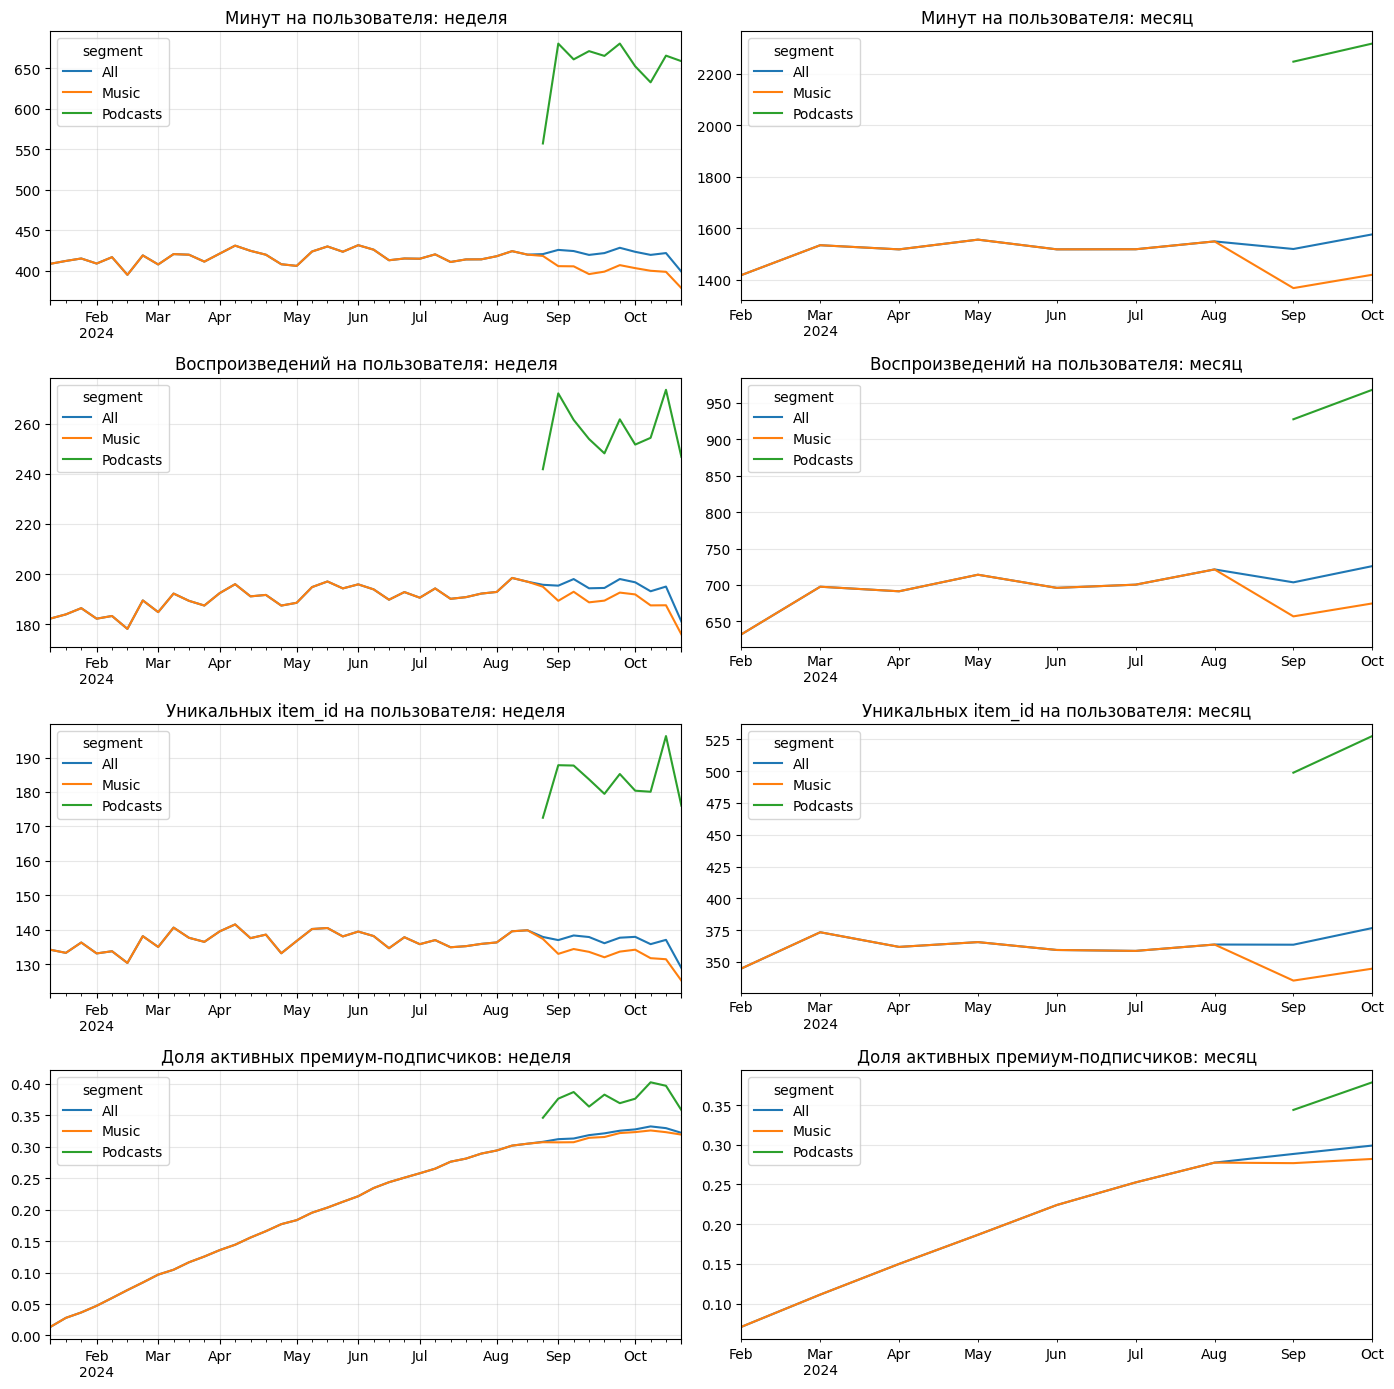

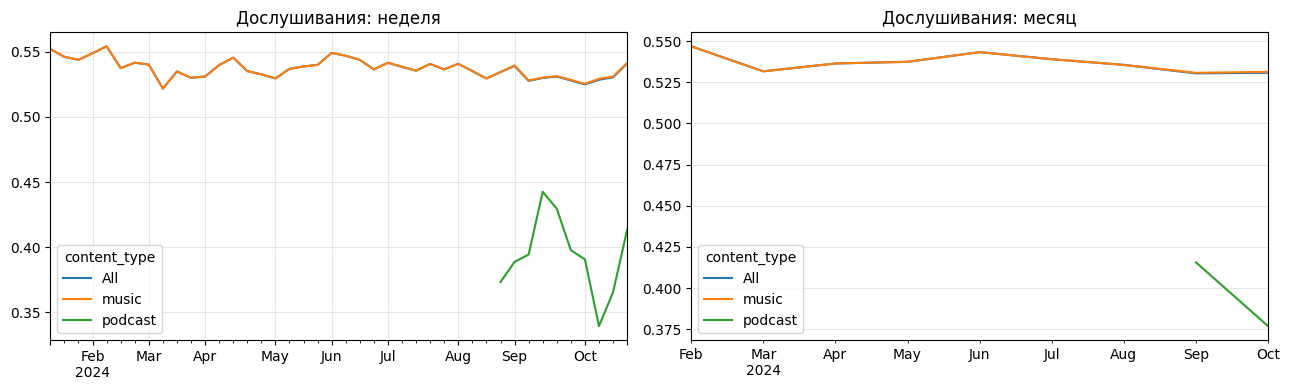

,period,segment,minutes,plays,unique_items,premium_share
12,2024-08-01,All,1549.270961,721.286605,363.654284,0.277522
13,2024-08-01,Music,1549.270961,721.286605,363.654284,0.277522
14,2024-09-01,All,1519.779167,703.548323,363.524720,0.288447
15,2024-09-01,Music,1367.910907,656.805255,335.294444,0.276877
16,2024-09-01,Podcasts,2247.435724,927.511511,498.786331,0.343885
17,2024-10-01,All,1576.550408,725.815058,376.625141,0.299005
18,2024-10-01,Music,1419.708826,674.571429,344.680455,0.282153
19,2024-10-01,Podcasts,2317.715708,967.970227,527.581877,0.378641


In [15]:
# your code is here

def product_metrics(periods):
    product_rows = []
    content_tables = []

    for period in periods:
        # Обрабатываем один период.
        mask = df_music_logs['datetime'].between(period.start_time, period.end_time)
        data = df_music_logs.loc[mask, ['uid', 'item_id', 'played_ratio_pct',
                                      'track_length_seconds', 'content_type']].copy()
        data['seconds'] = data['track_length_seconds'].astype(float) * data['played_ratio_pct'] / 100

        # Смотрим: достаточно одного подходящего эпизода именно в этом периоде.
        data['podcast_ok'] = (data['content_type'] == 'podcast') & (
            (data['played_ratio_pct'] >= 30) | (data['seconds'] > 120)
        )
        # Значения выше 100 оставляем в расчёте времени и считаем дослушанными.
        data['finished'] = data['played_ratio_pct'] >= 100

        users = data.groupby('uid').agg(
            minutes=('seconds', 'sum'),
            plays=('item_id', 'count'),
            unique_items=('item_id', 'nunique'),
            podcast_ok=('podcast_ok', 'max')
        )
        users['minutes'] = users['minutes'] / 60
        users['segment'] = users['podcast_ok'].map({True: 'Podcasts', False: 'Music'})

        active_subs = df_music_subs[
            (df_music_subs['start_date'] <= period.end_time) &
            (df_music_subs['end_date'].isna() | (df_music_subs['end_date'] > period.end_time))
        ]
        users['premium'] = users.index.isin(active_subs['uid'])

        for segment in ['All', 'Music', 'Podcasts']:
            group = users if segment == 'All' else users[users['segment'] == segment]
            if len(group) > 0:
                product_rows.append({
                    'period': period.start_time,
                    'segment': segment,
                    'minutes': group['minutes'].mean(),
                    'plays': group['plays'].mean(),
                    'unique_items': group['unique_items'].mean(),
                    'premium_share': group['premium'].mean()
                })

        # Дослушивания считаем по воспроизведениям, а не по пользователям.
        content = data.groupby('content_type', observed=True)['finished'].agg(['size', 'sum'])
        content.loc['All'] = [len(data), data['finished'].sum()]
        content['completion'] = content['sum'] / content['size']
        content['period'] = period.start_time
        content_tables.append(content.reset_index())

    return pd.DataFrame(product_rows), pd.concat(content_tables, ignore_index=True)

product_week, content_week = product_metrics(weeks)
product_month, content_month = product_metrics(months)

metrics = ['minutes', 'plays', 'unique_items', 'premium_share']
titles = ['Минут на пользователя', 'Воспроизведений на пользователя',
          'Уникальных item_id на пользователя', 'Доля активных премиум-подписчиков']

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for row, metric, title in zip(range(4), metrics, titles):
    for col, table, period_name in [(0, product_week, 'неделя'), (1, product_month, 'месяц')]:
        values = table.pivot(index='period', columns='segment', values=metric)
        values[['All', 'Music', 'Podcasts']].plot(ax=axes[row, col])
        axes[row, col].set_title(title + ': ' + period_name)
        axes[row, col].set_xlabel('')
        axes[row, col].grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, table, title in [(axes[0], content_week, 'Дослушивания: неделя'),
                         (axes[1], content_month, 'Дослушивания: месяц')]:
    values = table.pivot(index='period', columns='content_type', values='completion')
    values[['All', 'music', 'podcast']].plot(ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
product_month[product_month['period'] >= '2024-08-01']


**Выводы к заданию 4**

Число item_id с повторами показывает количество воспроизведений, без повторов — разнообразие контента. В показатели группы Podcasts входит всё её прослушивание, включая музыку. Группы определяются заново для каждого периода; короткие включения подкастов, не прошедшие порог, могут остаться в Music.

У All время на пользователя и разнообразие контента относительно стабильны, число воспроизведений немного увеличивается за год. Доля активных премиум-подписчиков растёт ещё до появления подкастов. Сразу после запуска резкого роста потребления у All нет: среднее время составляет 1 549 минут в августе, 1 520 в сентябре и 1 577 в октябре. Общая доля премиума за эти месяцы увеличилась с 27,75% до 29,90%.

У Podcasts показатели выше, чем у Music. В октябре это 2 318 минут против 1 420, 968 воспроизведений против 675 и 528 уникальных item_id против 345. Доля премиума — 37,86% против 28,22%. С сентября по октябрь месячные показатели потребления Podcasts выросли, хотя по неделям есть колебания.

Музыку дослушивают чаще: около 53% в сентябре и октябре. У подкастов доля дослушиваний снизилась примерно с 42% до 38%. Общий показатель дослушиваний близок к показателю музыки и не показывает резкого изменения после запуска.

Эти различия не доказывают влияние подкастов: их могли выбирать уже более активные пользователи. Состав Music меняется, поэтому снижение среднего потребления этой группы само по себе не доказывает, что пользователи стали меньше слушать музыку.

#### 5. Метрики продукта (шаг 2)  — 2 балла

Рассчитайте и визуализируйте:
1) D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.
2) D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.
3) D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

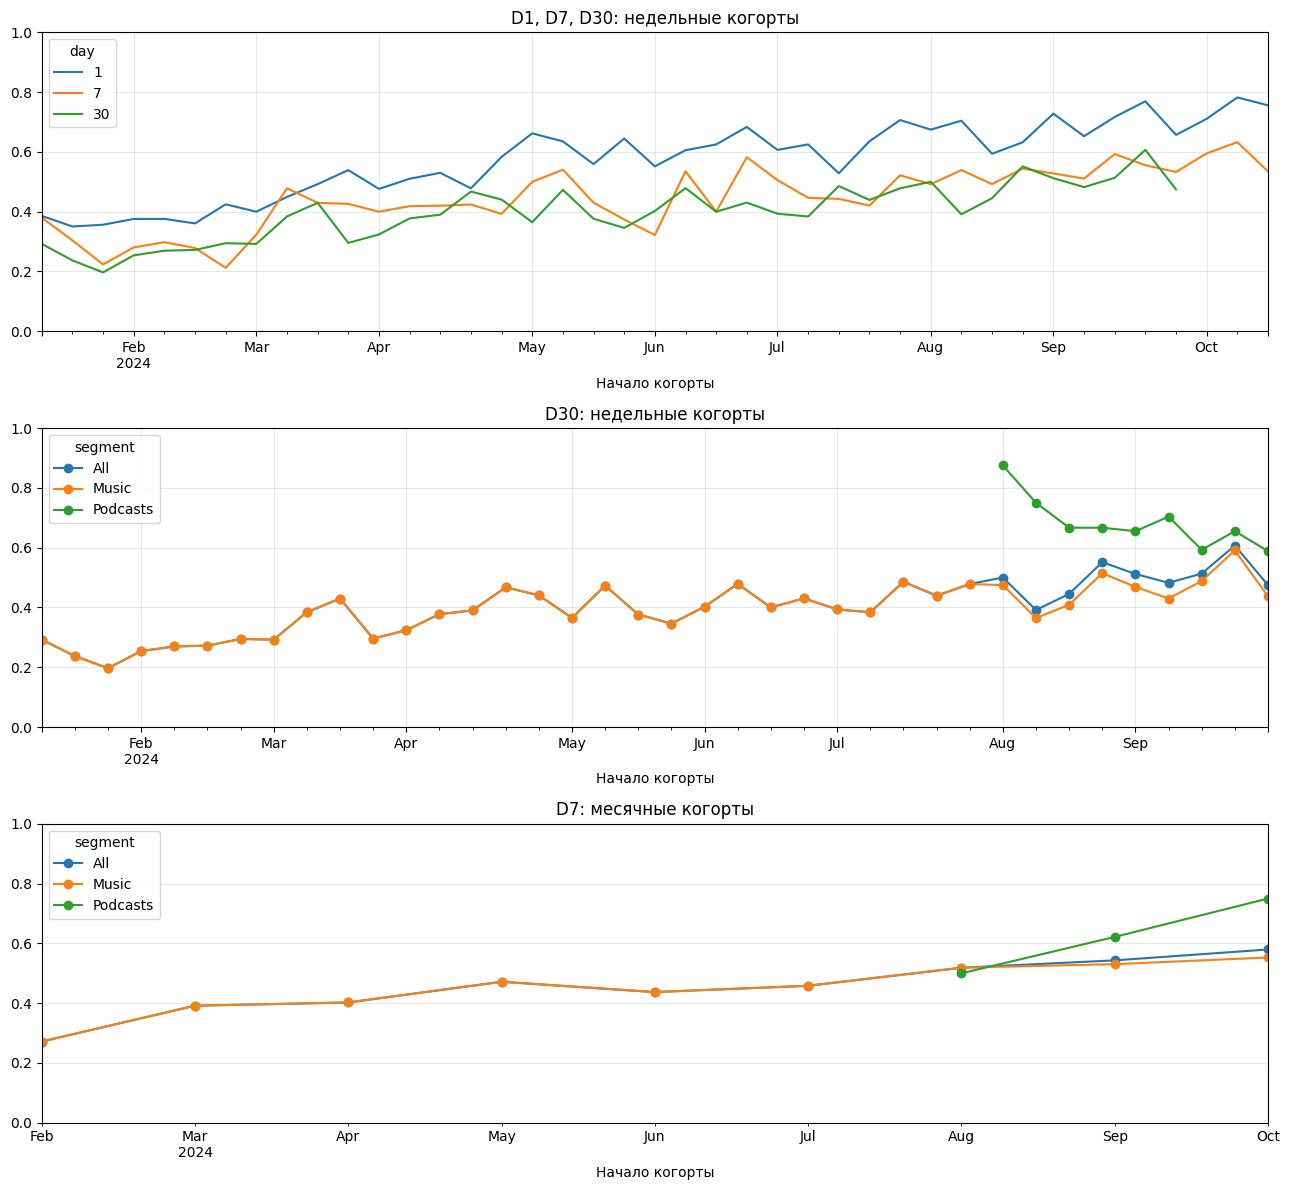

,cohort,segment,users,returned,retention
0,2024-02-01,All,681,185,0.271659
1,2024-02-01,Music,681,185,0.271659
2,2024-03-01,All,572,224,0.391608
3,2024-03-01,Music,572,224,0.391608
4,2024-04-01,All,425,171,0.402353
5,2024-04-01,Music,425,171,0.402353
6,2024-05-01,All,369,174,0.471545
7,2024-05-01,Music,369,174,0.471545
8,2024-06-01,All,350,153,0.437143
9,2024-06-01,Music,350,153,0.437143


In [16]:
# Новичков берём по флагу, а не по первому появлению в выгрузке.
new_users = df_music_logs[df_music_logs['is_first_date'] == 1].groupby('uid')['date'].min()
new_users = new_users.rename('first_date').reset_index()
activity = user_day[['uid', 'date']].merge(new_users, on='uid', how='inner')
activity['age'] = (activity['date'] - activity['first_date']).dt.days

podcast_seconds = podcasts['track_length_seconds'].astype(float) * podcasts['played_ratio_pct'] / 100
podcast_days = podcasts.loc[(podcasts['played_ratio_pct'] >= 30) | (podcast_seconds > 120),
                            ['uid', 'date']].drop_duplicates()
podcast_days = podcast_days.merge(new_users, on='uid', how='inner')
podcast_days['age'] = (podcast_days['date'] - podcast_days['first_date']).dt.days

def get_retention(day, freq, segments=False):
    users = new_users.copy()
    cohort = users['first_date'].dt.to_period(freq)
    users['cohort'] = cohort.dt.start_time

    # У всех участников полной когорты должен наступить нужный день.
    mature = (cohort.dt.start_time >= full_start) & (
        cohort.dt.end_time.dt.normalize() + timedelta(days=day) <= full_end
    )
    users = users[mature].copy()
    returned = activity.loc[activity['age'] == day, 'uid'].unique()
    users['returned'] = users['uid'].isin(returned)

    all_users = users.copy()
    all_users['segment'] = 'All'
    if segments:

        listened = podcast_days.loc[podcast_days['age'].between(0, day - 1), 'uid']
        users['segment'] = 'Music'
        users.loc[users['uid'].isin(listened), 'segment'] = 'Podcasts'
        users = pd.concat([all_users, users], ignore_index=True)
    else:
        users = all_users

    result = users.groupby(['cohort', 'segment']).agg(
        users=('uid', 'nunique'),
        returned=('returned', 'sum')
    ).reset_index()
    result['retention'] = result['returned'] / result['users']
    result['day'] = day
    return result

ret_week = pd.concat([get_retention(day, 'W-SUN') for day in [1, 7, 30]], ignore_index=True)
ret30_segments = get_retention(30, 'W-SUN', segments=True)
ret7_month = get_retention(7, 'M', segments=True)

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
ret_week.pivot(index='cohort', columns='day', values='retention').plot(ax=axes[0])
axes[0].set_title('D1, D7, D30: недельные когорты')

for ax, table, title in [(axes[1], ret30_segments, 'D30: недельные когорты'),
                         (axes[2], ret7_month, 'D7: месячные когорты')]:
    values = table.pivot(index='cohort', columns='segment', values='retention')
    values[['All', 'Music', 'Podcasts']].plot(ax=ax, marker='o')
    ax.set_title(title)
for ax in axes:
    ax.set_xlabel('Начало когорты')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ret7_month[['cohort', 'segment', 'users', 'returned', 'retention']]


**Выводы к заданию 5**

D1, D7 и D30 по недельным когортам в целом растут, хотя значения колеблются. Рост начался ещё до запуска подкастов. Общий D7 по месячным когортам увеличился с 27,17% в феврале до 51,85% в августе, 54,32% в сентябре и 57,96% в октябре. После запуска рост продолжается, но отдельный эффект подкастов от прежнего тренда по этим графикам не отделить.

В сентябре и октябре D7 у Podcasts выше: 62,16% и 75% против 53,06% и 55,28% у Music. В августе такого преимущества нет: 50% против 51,87%. Однако в августовской группе Podcasts всего 4 человека, поэтому её процент малоустойчив.

По показанным недельным когортам D30 у Podcasts также выше, чем у Music. При этом у самой группы Podcasts D30 в целом снижается от первых показанных когорт к более поздним, хотя остаётся выше Music.

Более высокое удержание Podcasts не доказывает, что его улучшили подкасты: их могли чаще выбирать пользователи, которые и без них активнее пользуются сервисом. Группа Podcasts встречается и у когорт до запуска, потому что первые 7 или 30 дней пользователя могут захватывать сентябрь.

#### 6. Приоритизация метрик  — 2 балла

Составьте список всех метрик, которые были рассчитаны выше (не забудьте, что показатель, рассчитанный в разрезе сегмента — это отдельная метрика). Для простоты давайте ориентироваться только на недельную агрегацию.

1. Присвойте метрикам приоритеты P0-P3 по принципу (в этом пункте стройте приоритизацию на уровне всей компании):
   -  P0 — бизнес результат;
   -  P1 — метрики продукта, напрямую аффектящие бизнес-результат (retention, product as a habit);
   -  P2 — метрики, отражающие взаимодействие пользователя с продуктом (user experience, user engagement) / таргет-метрики отдельных команд продукта;
   -  P3 — метрики стримов / опыт пользователя в рамках работы отдельных команд.
2. Пересоберите приоритеты только для команды подкастов, если цель развития подкастов — рост пользователей с подпиской. Обратите внимание, что вам не нужно отказываться от метрик, рассчитанных по всем пользователям (без сегментов) или для сегмента Music (полезно понимать, не каннибализируем ли мы основной тип контента). Скорее всего приоритеты изменятся только для посегментных метрик.
4. Представьте, что цель внедрения подкастов поменялась — теперь команда в первую очередь хочет задрайвить вовлеченность в продукт. Пересоберите приоритеты при необходимости (в данном пункте могут измениться приоритеты для метрик, рассчитанных по всем пользователям).

Для каждого из пунктов дайте краткое обоснование, почему вы присвоили приоритеты именно так.

**Ответ к заданию 6**

Music и Podcasts в пользовательских показателях — сегменты пользователей. В строках дослушивания music и podcast — типы контента. Время и воспроизведения группы Podcasts включают музыку тоже.

| Метрика | Компания | Подкасты: рост подписок | Подкасты: вовлечённость |
|---|:---:|:---:|:---:|
| WAU, All | P2 | P2 | P2 |
| Новые премиум-подписчики | P0 | P0 | P0 |
| Проникновение подкастов | P2 | P2 | P2 |
| Среднее время на пользователя, All | P2 | P2 | P1 |
| Среднее время на пользователя, Music | P3 | P3 | P2 |
| Среднее время на пользователя, Podcasts | P3 | P2 | P1 |
| Воспроизведений на пользователя, All | P2 | P2 | P2 |
| Воспроизведений на пользователя, Music | P3 | P3 | P2 |
| Воспроизведений на пользователя, Podcasts | P3 | P2 | P2 |
| Уникальных item_id на пользователя, All | P2 | P2 | P2 |
| Уникальных item_id на пользователя, Music | P3 | P3 | P2 |
| Уникальных item_id на пользователя, Podcasts | P3 | P2 | P2 |
| Доля премиума, All | P0 | P0 | P0 |
| Доля премиума, Music | P2 | P2 | P2 |
| Доля премиума, Podcasts | P2 | P0 | P2 |
| Доля дослушиваний, весь контент | P2 | P2 | P2 |
| Доля дослушиваний, music | P3 | P3 | P3 |
| Доля дослушиваний, podcast | P3 | P2 | P2 |
| D1 retention, All | P1 | P1 | P1 |
| D7 retention, All | P1 | P1 | P1 |
| D30 retention, All | P1 | P1 | P1 |
| D30 retention, Music | P2 | P2 | P2 |
| D30 retention, Podcasts | P2 | P1 | P1 |
| D7 retention, Music (месячные когорты) | P2 | P2 | P2 |
| D7 retention, Podcasts (месячные когорты) | P2 | P1 | P1 |

**1. Компания.** Новым премиум-подписчикам и общей доле премиума поставил P0 как доступным показателям монетизации. Выручки в данных нет; доля премиума служит её приближённым показателем и сама по себе не показывает рост числа платящих. Общее удержание — P1, потому что отражает возвращаемость. Среднее время, число воспроизведений и разнообразие контента — P2 как показатели вовлечённости. WAU также оставил в P2: он показывает размер аудитории, но не силу привычки. Подробности потребления в сегментах — P3.

**2. Команда подкастов, цель — подписки.** Долю премиума Podcasts поднял до P0 как показатель монетизации аудитории команды, а D30 этой группы — до P1. Показатели потребления Podcasts и дослушивания подкастов поднял до P2: они помогают понять поведение аудитории. Долю премиума нужно смотреть вместе с числом новых подписчиков: в Podcasts могли перейти люди, которые оплатили подписку раньше. По одной доле нельзя оценить, сколько новых оплат принесли подкасты. Общие показатели и Music сохраняются для контроля всего сервиса.

**3. Цель — вовлечённость.** Среднее время All и Podcasts поднял до P1 как основные показатели потребления для этой цели. Удержание сохраняет P1, чтобы рост времени сопровождался возвращаемостью. Долю премиума Podcasts вернул в P2. Включения, разнообразие и проникновение оставил в P2: они помогают объяснять взаимодействие, но сами по себе не показывают устойчивую привычку. Показатели Music также поднял до P2 для контроля основного сегмента. Его состав меняется, поэтому снижение среднего у Music само по себе не доказывает переток времени из музыки в подкасты.

В таблице в основном недельные показатели. Последние две строки относятся к месячным когортам, как в задании 5. Для DAU и MAU приоритеты такие же, как для WAU: P2 во всех сценариях. Месячный D7 All — P1. Месячные версии остальных показателей имеют те же приоритеты, что недельные.

Метрики игры и такси оставляю отдельно. Цели команды подкастов к ним не относятся.

| Продукт | Метрика | Приоритет | Почему |
|---|---|:---:|---|
| Игра | User Stickiness | P1 | Регулярность использования |
| Игра | ARPDAU | P0 | Выручка на пользователя |
| Игра | Paying Share | P0 | Монетизация аудитории |
| Игра | Sessions per User | P2 | Частота использования |
| Игра | Daily Play Time | P2 | Вовлечённость |
| Игра | Avg Attempts per Session | P3 | Деталь игрового процесса |
| Такси | Ride Completion Rate | P1 | Превращение заказа в поездку |
| Такси | Acceptance Rate | P2 | Принятие заказов водителями |
| Такси | Cancellation Rate | P2 | Потери заказов |
| Такси | Rides per Driver | P2 | Использование предложения водителей |
| Такси | Avg Ride Check | P0 | Денежный показатель поездки |
| Такси | RTA / ETA | P3 | Точность прогноза ожидания |

Денежные доли и средний чек рассматриваю как доступные показатели монетизации, но без объёма платящей аудитории или поездок они не заменяют выручку. Вспомогательные суммы для формул отдельно не приоритизирую. DAU и MAU игры — P2, выручка — P0.

